
# DATA 310 teaching-demo companion notebook

This notebook reproduces the **synthetic housing example** used in the UBC Okanagan teaching talk on multiple linear regression.

It is designed to do two things:

1. generate the plots/tables you may want to show in the lecture;
2. serve as a clean follow-up notebook that students can rerun after class.

## Learning goals

By the end of this notebook, you should be able to:

- interpret a coefficient in a multiple linear regression model;
- interpret a binary categorical predictor coded as 0/1;
- use residual plots to notice when a model is missing structure;
- understand what an interaction term changes.

## Packages used

- `numpy`
- `pandas`
- `matplotlib`
- `statsmodels`

All data are synthetic and are generated inside the notebook.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.nonparametric.smoothers_lowess import lowess

# Make plots look clean and readable in class / in exported HTML.
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

ASSET_DIR = Path("generated_assets")
ASSET_DIR.mkdir(exist_ok=True)

def save_table_png(df, filename, title=None):
    """Render a small dataframe as a PNG using matplotlib's table."""
    fig_h = 0.6 + 0.42 * len(df)
    fig, ax = plt.subplots(figsize=(10, fig_h))
    ax.axis("off")
    if title:
        ax.set_title(title, pad=12)
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.35)
    fig.tight_layout()
    outpath = ASSET_DIR / filename
    fig.savefig(outpath, bbox_inches="tight")
    plt.close(fig)
    return outpath

def tidy_coef_table(model, rename=None, digits=2):
    coef = model.params.rename("coef")
    se = model.bse.rename("std_err")
    tval = model.tvalues.rename("t")
    pval = model.pvalues.rename("p")
    ci = model.conf_int()
    ci.columns = ["ci_low", "ci_high"]
    out = pd.concat([coef, se, tval, pval, ci], axis=1).reset_index()
    out = out.rename(columns={"index": "term"})
    if rename is not None:
        out["term"] = out["term"].replace(rename)
    for col in ["coef", "std_err", "t", "p", "ci_low", "ci_high"]:
        out[col] = out[col].round(digits)
    return out

def add_lake_label(df, source_col="lake_view"):
    out = df.copy()
    out["LakeView"] = np.where(out[source_col] == 1, "Yes", "No")
    return out



## 1. Generate a clean additive housing dataset

This first dataset is used for the main part of the lecture.

The variables are:

- `price_k`: house price in **thousands of dollars**
- `size_100sqft`: house size measured in **hundreds of square feet**
- `age_years`: house age in years
- `distance_km`: distance to downtown in km
- `lake_view`: 1 for **Yes**, 0 for **No**

The data-generating process is linear, so the fitted additive model should be easy to interpret.


In [2]:

rng = np.random.default_rng(42)
n = 220

size_100sqft = np.clip(rng.normal(19, 4, n), 8, 35)
age_years = np.clip(rng.normal(20, 12, n), 0, 60)
distance_km = np.clip(rng.normal(8, 4, n), 0.5, 25)
lake_view = rng.binomial(1, 0.30, n)

price_k = (
    75
    + 18 * size_100sqft
    - 1.5 * age_years
    - 9 * distance_km
    + 110 * lake_view
    + rng.normal(0, 20, n)
)

housing = pd.DataFrame(
    {
        "price_k": price_k,
        "size_100sqft": size_100sqft,
        "age_years": age_years,
        "distance_km": distance_km,
        "lake_view": lake_view,
    }
)

housing["LakeView"] = np.where(housing["lake_view"] == 1, "Yes", "No")
housing.round(2).head(8)


,price_k,size_100sqft,age_years,distance_km,lake_view,LakeView
0,418.61,20.22,17.31,7.24,1,Yes
1,333.68,14.84,22.91,9.31,1,Yes
2,348.41,22.00,22.12,9.45,0,No
3,352.63,22.76,6.99,13.28,0,No
4,294.68,11.20,21.09,6.63,1,Yes
5,274.81,13.79,22.74,2.09,0,No
6,259.42,19.51,50.21,12.27,0,No
7,358.16,17.74,42.52,6.67,1,Yes


Saving a neat table image for slides.


In [3]:

snapshot = housing[["price_k", "size_100sqft", "age_years", "distance_km", "LakeView"]].head(8).round(1)
display(snapshot)
snapshot_path = save_table_png(snapshot, "01_data_snapshot.png", title="Illustrative housing data snapshot")
snapshot_path


,price_k,size_100sqft,age_years,distance_km,LakeView
0,418.6,20.2,17.3,7.2,Yes
1,333.7,14.8,22.9,9.3,Yes
2,348.4,22.0,22.1,9.4,No
3,352.6,22.8,7.0,13.3,No
4,294.7,11.2,21.1,6.6,Yes
5,274.8,13.8,22.7,2.1,No
6,259.4,19.5,50.2,12.3,No
7,358.2,17.7,42.5,6.7,Yes


PosixPath('generated_assets/01_data_snapshot.png')


## 2. One motivating visual

A simple first visual is `price` versus `size`, colored by lake view.
This is not yet the regression model; it is just a way to start the conversation.


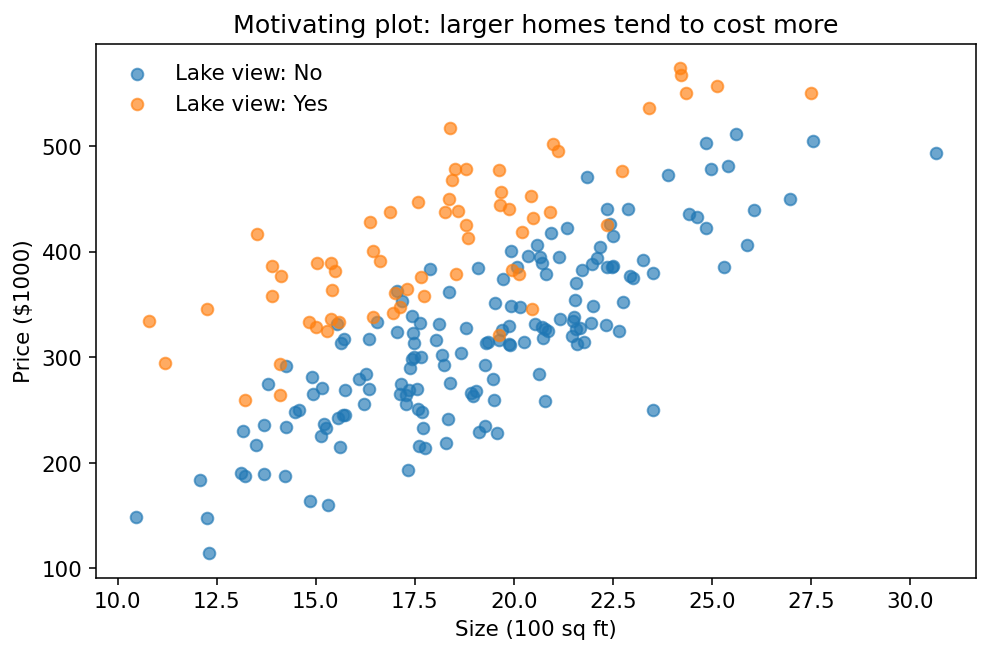

PosixPath('generated_assets/02_motivating_scatter.png')

In [4]:

fig, ax = plt.subplots(figsize=(7.2, 4.8))

for label, color in [("No", "tab:blue"), ("Yes", "tab:orange")]:
    mask = housing["LakeView"] == label
    ax.scatter(
        housing.loc[mask, "size_100sqft"],
        housing.loc[mask, "price_k"],
        alpha=0.65,
        label=f"Lake view: {label}",
        color=color,
    )

ax.set_xlabel("Size (100 sq ft)")
ax.set_ylabel("Price ($1000)")
ax.set_title("Motivating plot: larger homes tend to cost more")
ax.legend()

fig.tight_layout()
motivating_plot_path = ASSET_DIR / "02_motivating_scatter.png"
fig.savefig(motivating_plot_path, bbox_inches="tight")
plt.show()

motivating_plot_path



## 3. Fit the main additive model

This is the model that matches the early part of the lecture:

\[
\text{Price} = \beta_0 + \beta_1\,\text{Size} + \beta_2\,\text{Age}
+ \beta_3\,\text{Distance} + \beta_4\,\text{LakeView} + \varepsilon
\]

Because `lake_view` is coded 0/1, its coefficient is an adjusted comparison between the two groups.


In [5]:

main_model = smf.ols(
    "price_k ~ size_100sqft + age_years + distance_km + lake_view",
    data=housing
).fit()

main_table = tidy_coef_table(
    main_model,
    rename={
        "Intercept": "Intercept",
        "size_100sqft": "Size (100 sq ft)",
        "age_years": "Age (years)",
        "distance_km": "Distance (km)",
        "lake_view": "LakeView = Yes",
    }
)

display(main_table)
main_table.to_csv(ASSET_DIR / "03_main_model_coefficients.csv", index=False)
main_table_png = save_table_png(
    main_table,
    "03_main_model_coefficients.png",
    title="Main additive model: coefficient table"
)
main_table_png


,term,coef,std_err,t,p,ci_low,ci_high
0,Intercept,74.53,8.39,8.88,0.0,57.99,91.08
1,Size (100 sq ft),18.24,0.38,48.21,0.0,17.49,18.98
2,Age (years),-1.53,0.11,-13.52,0.0,-1.75,-1.30
3,Distance (km),-9.39,0.33,-28.54,0.0,-10.04,-8.74
4,LakeView = Yes,108.34,2.94,36.85,0.0,102.55,114.14


PosixPath('generated_assets/03_main_model_coefficients.png')


These coefficients match the values used in the teaching slides:

- Size ≈ +18 thousand dollars per additional 100 sq ft
- Age ≈ -1.5 thousand dollars per additional year
- Distance ≈ -9 thousand dollars per additional km
- Lake view ≈ +110 thousand dollars for otherwise comparable homes


In [6]:

print(main_model.summary())


                            OLS Regression Results                            
Dep. Variable:                price_k   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     1104.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.75e-142
Time:                        19:43:31   Log-Likelihood:                -960.86
No. Observations:                 220   AIC:                             1932.
Df Residuals:                     215   BIC:                             1949.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       74.5339      8.393      8.881   


## 4. A few classroom interpretation checks

These cells generate the numerical examples used in the talk.


In [7]:

beta_distance = main_model.params["distance_km"]
print(
    f"If two otherwise comparable homes differ only by 1 km in distance to downtown, "
    f"the model predicts about {beta_distance:.1f} thousand dollars in price difference."
)


If two otherwise comparable homes differ only by 1 km in distance to downtown, the model predicts about -9.4 thousand dollars in price difference.


In [8]:

beta_lake = main_model.params["lake_view"]
print(
    f"If two otherwise comparable homes differ only in lake view, "
    f"the model predicts about {beta_lake:.1f} thousand dollars higher price for the lake-view home."
)


If two otherwise comparable homes differ only in lake view, the model predicts about 108.3 thousand dollars higher price for the lake-view home.



## 5. Visualize the effect of a binary categorical predictor

Without an interaction term, the two fitted lines are **parallel**.
That means the model allows a different intercept by group, but not a different slope.


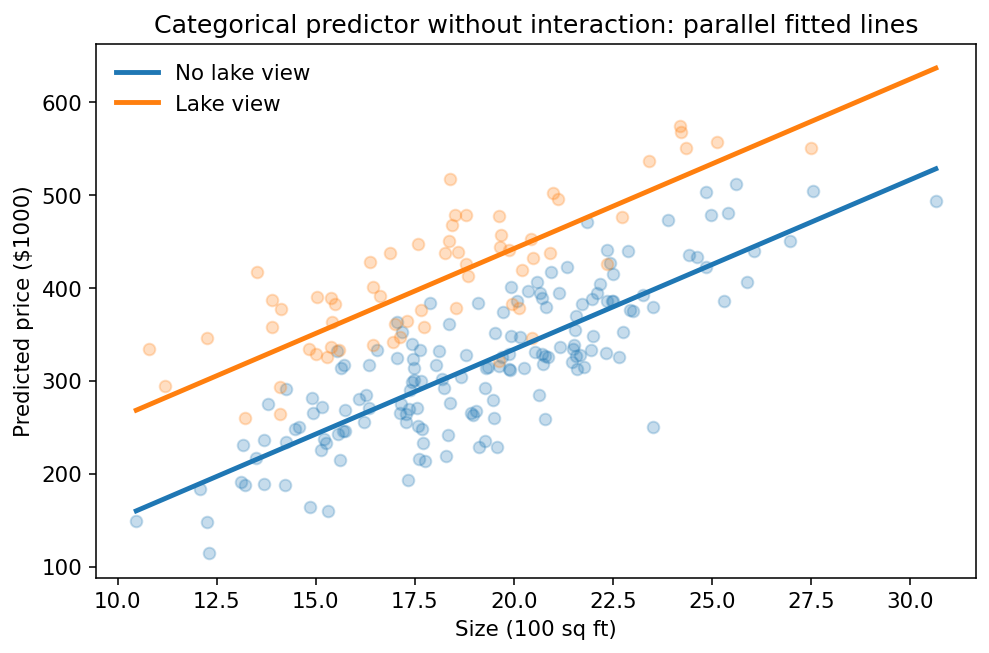

PosixPath('generated_assets/04_parallel_lines_categorical_predictor.png')

In [9]:

grid_size = np.linspace(housing["size_100sqft"].min(), housing["size_100sqft"].max(), 120)
reference_age = 20
reference_distance = 8

pred_no = pd.DataFrame(
    {
        "size_100sqft": grid_size,
        "age_years": reference_age,
        "distance_km": reference_distance,
        "lake_view": 0,
    }
)
pred_yes = pred_no.copy()
pred_yes["lake_view"] = 1

pred_no["pred_price_k"] = main_model.predict(pred_no)
pred_yes["pred_price_k"] = main_model.predict(pred_yes)

fig, ax = plt.subplots(figsize=(7.2, 4.8))

# Light scatter in background
for label, color in [("No", "tab:blue"), ("Yes", "tab:orange")]:
    mask = housing["LakeView"] == label
    ax.scatter(
        housing.loc[mask, "size_100sqft"],
        housing.loc[mask, "price_k"],
        alpha=0.25,
        color=color
    )

ax.plot(pred_no["size_100sqft"], pred_no["pred_price_k"], linewidth=2.5, label="No lake view", color="tab:blue")
ax.plot(pred_yes["size_100sqft"], pred_yes["pred_price_k"], linewidth=2.5, label="Lake view", color="tab:orange")

ax.set_xlabel("Size (100 sq ft)")
ax.set_ylabel("Predicted price ($1000)")
ax.set_title("Categorical predictor without interaction: parallel fitted lines")
ax.legend()

fig.tight_layout()
parallel_plot_path = ASSET_DIR / "04_parallel_lines_categorical_predictor.png"
fig.savefig(parallel_plot_path, bbox_inches="tight")
plt.show()

parallel_plot_path



## 6. A second dataset for diagnostics and model revision

To show why residuals matter, it helps to look at a case where the additive model is **slightly wrong**.

In the next synthetic dataset, the true data-generating process includes an interaction between `size` and `lake_view`.
That lets us show:

- a misspecified additive model;
- a better model with an interaction;
- how the residual structure improves.


In [10]:
rng = np.random.default_rng(123)
n = 180

size_100sqft = np.clip(rng.normal(19, 3.5, n), 10, 30)
age_years = np.clip(rng.normal(20, 10, n), 0, 50)
distance_km = np.clip(rng.normal(8, 3, n), 1, 18)
lake_view = rng.binomial(1, 0.45, n)

# Make the interaction visually obvious:
# - lower noise
# - stronger slope difference between groups
# - enough observations in both groups
price_k = (
    80
    + 13.5 * size_100sqft
    - 1.0 * age_years
    - 7.5 * distance_km
    + 45 * lake_view
    + 7.5 * size_100sqft * lake_view
    + rng.normal(0, 10, n)
)

housing_interact = pd.DataFrame(
    {
        "price_k": price_k,
        "size_100sqft": size_100sqft,
        "age_years": age_years,
        "distance_km": distance_km,
        "lake_view": lake_view,
    }
)
housing_interact["LakeView"] = np.where(housing_interact["lake_view"] == 1, "Yes", "No")

bad_model = smf.ols(
    "price_k ~ size_100sqft + age_years + distance_km + lake_view",
    data=housing_interact
).fit()

good_model = smf.ols(
    "price_k ~ size_100sqft * lake_view + age_years + distance_km",
    data=housing_interact
).fit()

bad_model.params.round(2), good_model.params.round(2)

(Intercept        22.73
 size_100sqft     16.54
 age_years        -0.92
 distance_km      -7.90
 lake_view       190.35
 dtype: float64,
 Intercept                 81.46
 size_100sqft              13.45
 lake_view                 46.15
 size_100sqft:lake_view     7.47
 age_years                 -0.96
 distance_km               -7.59
 dtype: float64)


### Residual comparison

Below, the left panel shows residuals from the misspecified additive model.
The right panel shows residuals after adding the interaction.

For teaching, this is a nice place to say:

> Residuals should look patternless around zero. If they show structure, the model is systematically missing something.


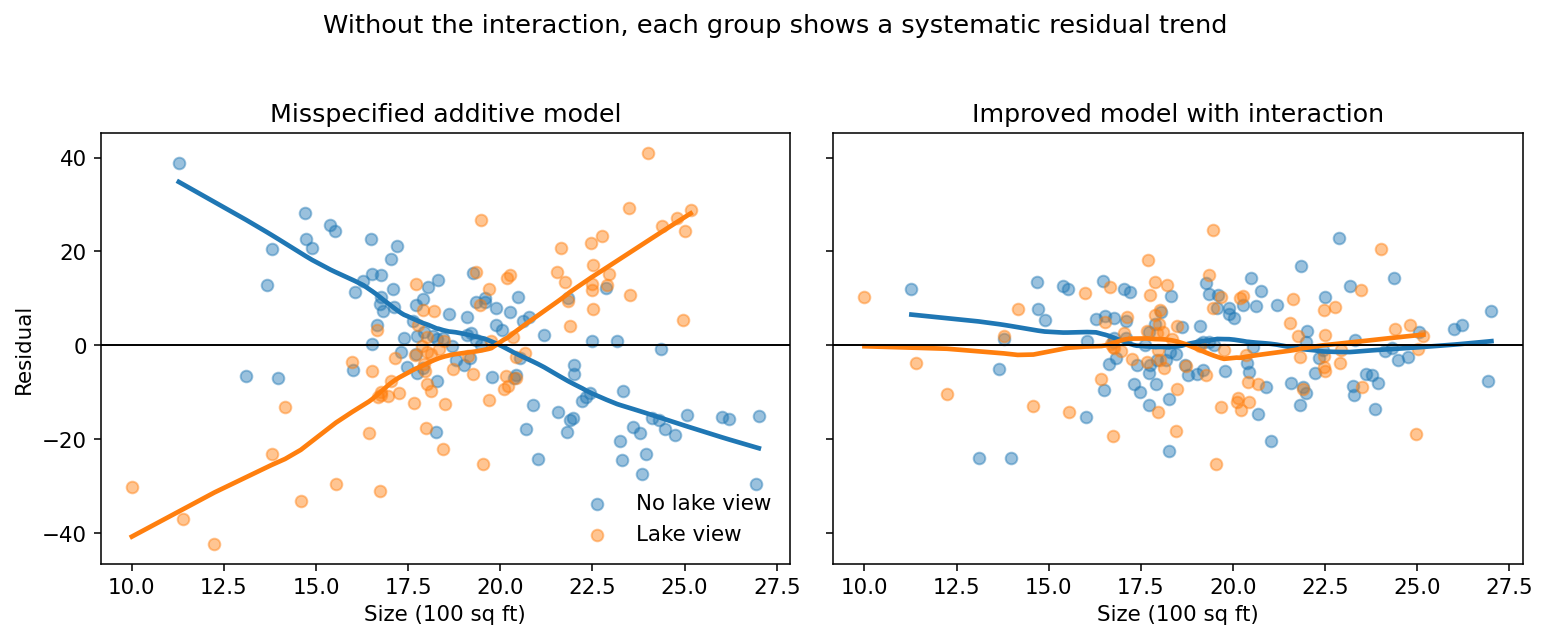

PosixPath('generated_assets/05_residuals_bad_vs_better_model.png')

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.4), sharey=True)

for panel, (model, title) in enumerate(
    [
        (bad_model, "Misspecified additive model"),
        (good_model, "Improved model with interaction"),
    ]
):
    for group, color, label in [(0, "tab:blue", "No lake view"), (1, "tab:orange", "Lake view")]:
        mask = housing_interact["lake_view"] == group
        x = housing_interact.loc[mask, "size_100sqft"]
        y = model.resid[mask]

        ax[panel].scatter(x, y, alpha=0.45, color=color, label=label)
        smooth = lowess(y, x, frac=0.55, return_sorted=True)
        ax[panel].plot(smooth[:, 0], smooth[:, 1], color=color, linewidth=2.4)

    ax[panel].axhline(0, color="black", linewidth=1)
    ax[panel].set_xlabel("Size (100 sq ft)")
    ax[panel].set_title(title)

ax[0].set_ylabel("Residual")
ax[0].legend()

fig.suptitle("Without the interaction, each group shows a systematic residual trend", y=1.03)
fig.tight_layout()

residual_plot_path = ASSET_DIR / "05_residuals_bad_vs_better_model.png"
fig.savefig(residual_plot_path, bbox_inches="tight")
plt.show()

residual_plot_path


## 7. Fit and interpret the interaction model

The interaction model is:

\[
\text{Price} = \beta_0 + \beta_1\,\text{Size} + \beta_2\,\text{LakeView}
+ \beta_3\,(\text{Size} \times \text{LakeView})
+ \beta_4\,\text{Age} + \beta_5\,\text{Distance} + \varepsilon
\]

Here, a positive `Size × LakeView` coefficient means:

> the slope of size is larger for lake-view homes.


In [12]:

interaction_table = tidy_coef_table(
    good_model,
    rename={
        "Intercept": "Intercept",
        "size_100sqft": "Size (100 sq ft)",
        "lake_view": "LakeView = Yes",
        "size_100sqft:lake_view": "Size × LakeView",
        "age_years": "Age (years)",
        "distance_km": "Distance (km)",
    }
)

display(interaction_table)
interaction_table.to_csv(ASSET_DIR / "06_interaction_model_coefficients.csv", index=False)
interaction_table_png = save_table_png(
    interaction_table,
    "06_interaction_model_coefficients.png",
    title="Interaction model: coefficient table"
)
interaction_table_png


,term,coef,std_err,t,p,ci_low,ci_high
0,Intercept,81.46,6.14,13.27,0.0,69.34,93.58
1,Size (100 sq ft),13.45,0.30,45.46,0.0,12.87,14.04
2,LakeView = Yes,46.15,9.01,5.12,0.0,28.36,63.93
3,Size × LakeView,7.47,0.46,16.22,0.0,6.56,8.38
4,Age (years),-0.96,0.07,-13.40,0.0,-1.10,-0.82
5,Distance (km),-7.59,0.24,-31.03,0.0,-8.07,-7.10


PosixPath('generated_assets/06_interaction_model_coefficients.png')

In [13]:

interaction_coef = good_model.params["size_100sqft:lake_view"]
print(
    f"The Size × LakeView coefficient is {interaction_coef:.2f}. "
    f"Because it is positive, the slope of size is larger for lake-view homes."
)


The Size × LakeView coefficient is 7.47. Because it is positive, the slope of size is larger for lake-view homes.



## 8. Compare fitted lines: no interaction vs interaction


- Left: additive model → **parallel lines**
- Right: interaction model → **different slopes**


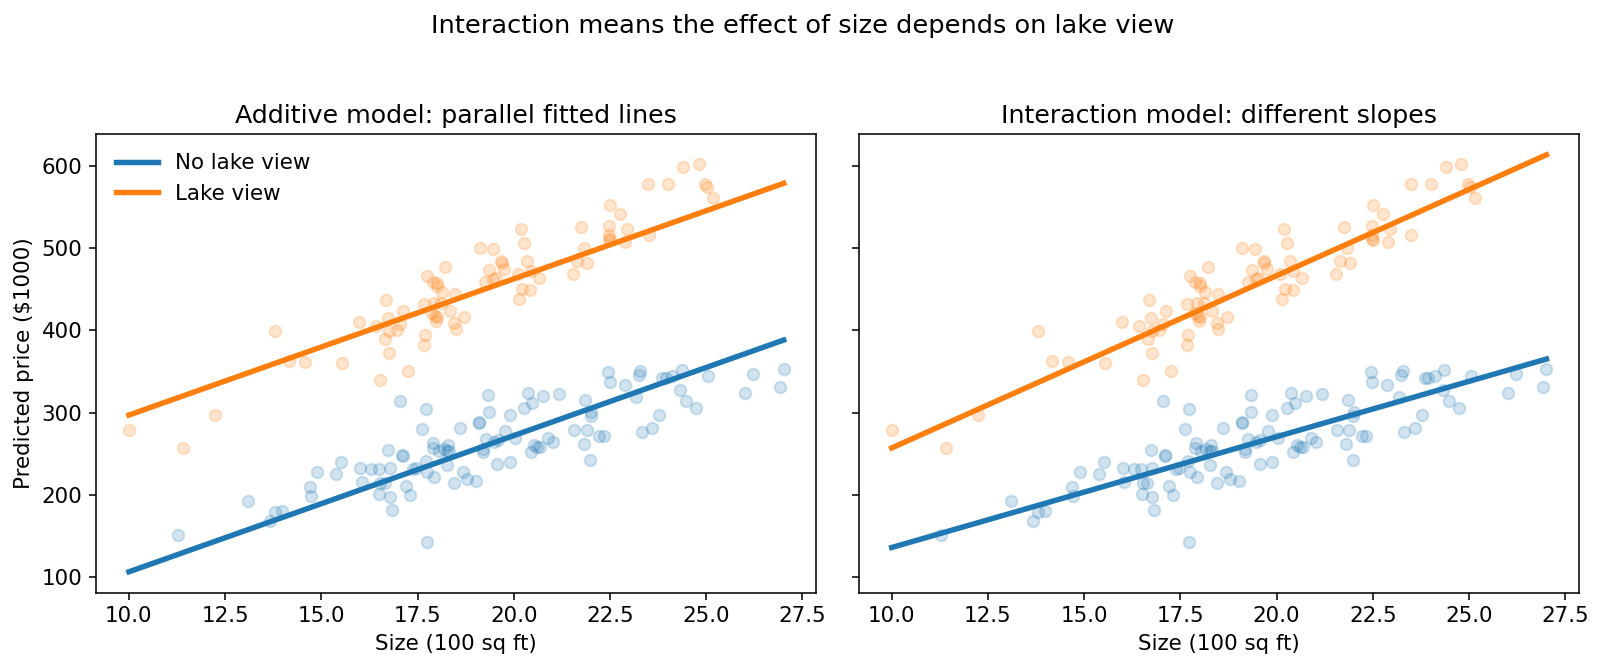

PosixPath('generated_assets/07_no_interaction_vs_interaction_lines.png')

In [14]:
grid_size = np.linspace(housing_interact["size_100sqft"].min(), housing_interact["size_100sqft"].max(), 120)
reference_age = 20
reference_distance = 8

grid_no = pd.DataFrame(
    {
        "size_100sqft": grid_size,
        "age_years": reference_age,
        "distance_km": reference_distance,
        "lake_view": 0,
    }
)
grid_yes = grid_no.copy()
grid_yes["lake_view"] = 1

grid_no["pred_bad"] = bad_model.predict(grid_no)
grid_yes["pred_bad"] = bad_model.predict(grid_yes)
grid_no["pred_good"] = good_model.predict(grid_no)
grid_yes["pred_good"] = good_model.predict(grid_yes)

fig, ax = plt.subplots(1, 2, figsize=(11.6, 4.6), sharey=True)

for group, color, label in [(0, "tab:blue", "No lake view"), (1, "tab:orange", "Lake view")]:
    mask = housing_interact["lake_view"] == group
    for panel in range(2):
        ax[panel].scatter(
            housing_interact.loc[mask, "size_100sqft"],
            housing_interact.loc[mask, "price_k"],
            alpha=0.20,
            color=color
        )

# No interaction panel
ax[0].plot(grid_no["size_100sqft"], grid_no["pred_bad"], linewidth=2.8, label="No lake view", color="tab:blue")
ax[0].plot(grid_yes["size_100sqft"], grid_yes["pred_bad"], linewidth=2.8, label="Lake view", color="tab:orange")
ax[0].set_title("Additive model: parallel fitted lines")
ax[0].set_xlabel("Size (100 sq ft)")
ax[0].set_ylabel("Predicted price ($1000)")
ax[0].legend()

# Interaction panel
ax[1].plot(grid_no["size_100sqft"], grid_no["pred_good"], linewidth=2.8, label="No lake view", color="tab:blue")
ax[1].plot(grid_yes["size_100sqft"], grid_yes["pred_good"], linewidth=2.8, label="Lake view", color="tab:orange")
ax[1].set_title("Interaction model: different slopes")
ax[1].set_xlabel("Size (100 sq ft)")

fig.suptitle("Interaction means the effect of size depends on lake view", y=1.03)
fig.tight_layout()

interaction_plot_path = ASSET_DIR / "07_no_interaction_vs_interaction_lines.png"
fig.savefig(interaction_plot_path, bbox_inches="tight")
plt.show()

interaction_plot_path


## 9. What files did we generate?

The notebook saves every key visual/table into `generated_assets/`.
That makes it easy to pull the outputs into slides.


In [15]:

sorted([p.name for p in ASSET_DIR.iterdir()])


['01_data_snapshot.png',
 '02_motivating_scatter.png',
 '03_main_model_coefficients.csv',
 '03_main_model_coefficients.png',
 '04_parallel_lines_categorical_predictor.png',
 '05_residuals_bad_vs_better_model.png',
 '06_interaction_model_coefficients.csv',
 '06_interaction_model_coefficients.png',
 '07_no_interaction_vs_interaction_lines.png']